# Saliency Maps

In [ ]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pkg.saliency_maps.compute_gradient import run_forecast_with_gradients

## Run Forecast

In [ ]:
run_forecast_with_gradients(
    model_name="graphcast_small",
    input_data_or_path="../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc",
    output_name="zeynep_wind_grad",
    target_lat=54.0,
    target_lon=9.0,
    lead_hours=6
)


## Visualize Results

In [22]:
saliency_path = "data/predictions/zeynep_wind_grad_saliency.nc"
input_path = "../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"  

sal_ds = xr.open_dataset(saliency_path)
input_ds = xr.open_dataset(input_path)


In [ ]:
# Compute mean(|saliency|) for each feature
scores = []
for var in sal_ds.data_vars:
    da = sal_ds[var]
    # use built-in abs to get a DataArray of absolute values
    mean_abs = float(abs(da).mean().item())   # .item() to get a Python float
    scores.append((var, mean_abs))

# Build a DataFrame and sort descending
df = pd.DataFrame(scores, columns=["feature", "mean_abs_saliency"])
df = df.sort_values("mean_abs_saliency", ascending=False).reset_index(drop=True)

print(df)


                                  feature  mean_abs_saliency
0              specific_humidity_saliency       1.579708e+00
1              year_progress_cos_saliency       1.552856e-02
2              year_progress_sin_saliency       1.494473e-02
3        total_precipitation_6hr_saliency       6.515224e-03
4               day_progress_sin_saliency       4.364748e-04
5               day_progress_cos_saliency       4.364442e-04
6                  land_sea_mask_saliency       2.411337e-04
7              vertical_velocity_saliency       2.714802e-05
8                 2m_temperature_saliency       4.797425e-06
9                    temperature_saliency       2.477898e-06
10       10m_u_component_of_wind_saliency       2.227683e-06
11       10m_v_component_of_wind_saliency       1.776635e-06
12           u_component_of_wind_saliency       1.337980e-06
13           v_component_of_wind_saliency       1.302885e-06
14       mean_sea_level_pressure_saliency       5.690766e-08
15                  geop

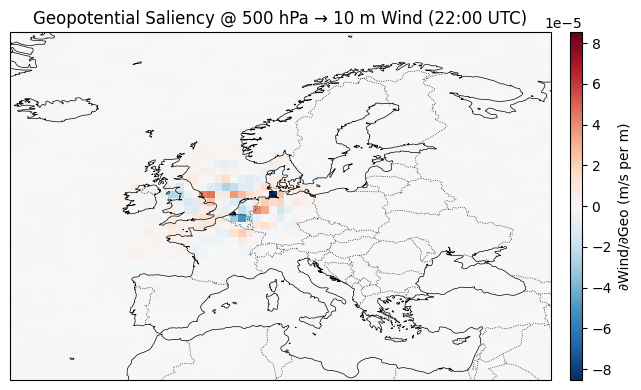

In [ ]:
# load
sal_ds   = xr.open_dataset("data/predictions/zeynep_wind_grad_saliency.nc")
input_ds = xr.open_dataset("../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc")

# pick a 2D slice
da = sal_ds["geopotential_saliency"]
levels = input_ds["level"].values
idx500 = int(np.argmin(np.abs(levels-500)))
da2d = da.isel(batch=0, time=-1, level=idx500)

# **re-attach** the real coords
da2d = da2d.assign_coords(
    lat = input_ds["lat"],
    lon = input_ds["lon"]
)

# plot with cartopy
fig, ax = plt.subplots(
    figsize=(10,4),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

pcm = da2d.plot.pcolormesh(
    ax=ax,
    x="lon", y="lat",
    cmap="RdBu_r",
    vmin=-np.abs(da2d).max(),
    vmax= np.abs(da2d).max(),
    add_colorbar=False,
    transform=ccrs.PlateCarree()
)

# add borders/coastlines
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.5)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":", linewidth=0.5) 

ax.set_extent([-25, 45, 30, 75], crs=ccrs.PlateCarree()) # zoom into Europe
# ax.set_global() 

cbar = fig.colorbar(pcm, ax=ax, orientation="vertical", pad=0.02, aspect=30)
cbar.set_label("∂Wind/∂Geo (m/s per m)")

ax.set_title("Geopotential Saliency @ 500 hPa → 10 m Wind (22:00 UTC)")
plt.tight_layout()
plt.show()


In [25]:
def plot_atmospheric_saliency(
    sal_ds: xr.Dataset,
    input_ds: xr.Dataset,
    varname: str,
    target_level: float,
    time_index: int = -1,
    batch_index: int = 0,
    extent: list = [-25, 45, 30, 75],
    cmap: str = "RdBu_r",
    title: str | None = None
):
    """
    Plot a single‐level atmospheric saliency map over Europe.

    Parameters
    ----------
    sal_ds : xr.Dataset
        Saliency dataset containing '<varname>_saliency' with dims
        (batch, time, level, lat, lon).
    input_ds : xr.Dataset
        Original input dataset, used for real 'level', 'lat', 'lon' coords.
    varname : str
        Base variable name, e.g. "geopotential", "temperature", etc.
    target_level : float
        The pressure level (hPa) to slice, e.g. 500.
    time_index : int
        Which time index to plot (default: -1, the last one).
    batch_index : int
        Which batch index to plot (default: 0).
    extent : list
        [lon_min, lon_max, lat_min, lat_max] for the map extent.
    cmap : str
        Matplotlib colormap.
    title : str or None
        If given, use this as the plot title; otherwise a default is built.
    """
    da = sal_ds[f"{varname}_saliency"]
    # find integer index of the nearest level in input_ds
    levels = input_ds["level"].values
    lvl_idx = int(np.argmin(np.abs(levels - target_level)))

    # slice out the 2D field
    da2d = da.isel(batch=batch_index, time=time_index, level=lvl_idx)

    # re‐attach real lat/lon coords
    da2d = da2d.assign_coords(
        lat=input_ds["lat"],
        lon=input_ds["lon"]
    )

    # build the figure with Cartopy
    fig, ax = plt.subplots(
        figsize=(10,4),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    pcm = da2d.plot.pcolormesh(
        ax=ax,
        x="lon", y="lat",
        cmap=cmap,
        vmin=-np.abs(da2d).max(),
        vmax= np.abs(da2d).max(),
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.5)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":", linewidth=0.5)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    cbar = fig.colorbar(pcm, ax=ax, orientation="vertical", pad=0.02, aspect=30)
    cbar.set_label(f"∂Wind/∂{varname.replace('_',' ').title()}")

    if title is None:
        title = (
            f"{varname.replace('_',' ').title()} Saliency @ "
            f"{levels[lvl_idx]:.0f} hPa → 10 m Wind"
        )
    ax.set_title(title + f" (t={time_index}, batch={batch_index})")
    plt.tight_layout()
    plt.show()


In [37]:
def plot_surface_saliency(
    ds_sal: xr.Dataset,
    input_ds: xr.Dataset,
    varname: str,
    time_index: int = -1,
    extent: list = [-25, 45, 30, 75],
    cmap: str = "RdBu_r"
):
    """
    Plot a surface‐only saliency field (no level dim) on a European map.
    
    Parameters
    ----------
    ds_sal : xr.Dataset
      Dataset containing `<varname>_saliency` with dims (batch, time, lat, lon).
    input_ds : xr.Dataset
      Original input, used for lat/lon coords.
    varname : str
      The base variable name, e.g. "2m_temperature" or "mean_sea_level_pressure".
    extent : list
      [lon_min, lon_max, lat_min, lat_max] for map zoom.
    cmap : str
      A matplotlib colormap name.
    """
    da = ds_sal[f"{varname}_saliency"]  # dims: (batch, time, lat, lon)

    # pick batch=0, last time
    da2d = da.isel(batch=0, time=time_index)

    # re‐attach real lat/lon coords
    da2d = da2d.assign_coords(lat=input_ds["lat"], lon=input_ds["lon"])

    # plot
    fig, ax = plt.subplots(
        figsize=(8, 5),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )
    pcm = da2d.plot.pcolormesh(
        ax=ax,
        x="lon", y="lat",
        cmap=cmap,
        vmin=-np.abs(da2d).max(),
        vmax= np.abs(da2d).max(),
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.5)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":", linewidth=0.5)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    cbar = fig.colorbar(pcm, ax=ax, orientation="vertical", pad=0.02, aspect=30)
    cbar.set_label(f"∂Wind/∂{varname.replace('_',' ').title()}")

    ax.set_title(f"{varname.replace('_',' ').title()} Saliency → 10 m Wind (22:00 UTC)")
    plt.tight_layout()
    plt.show()



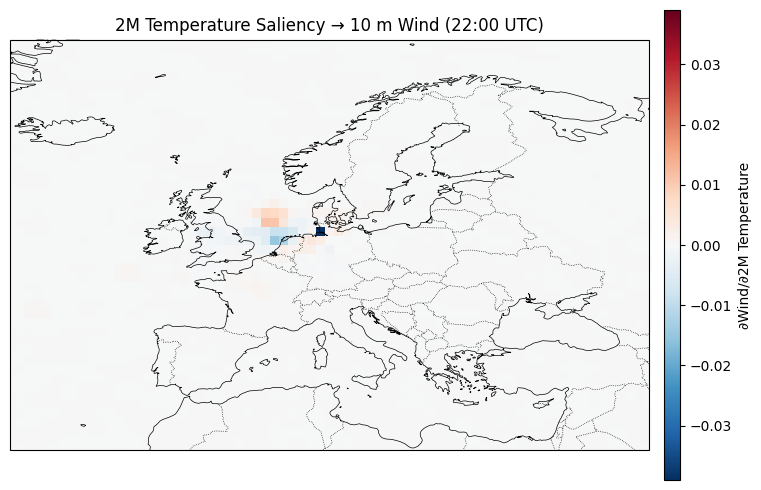

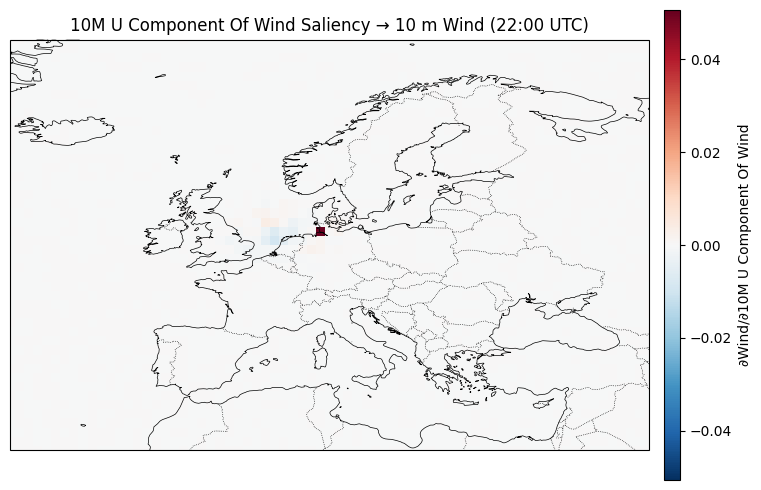

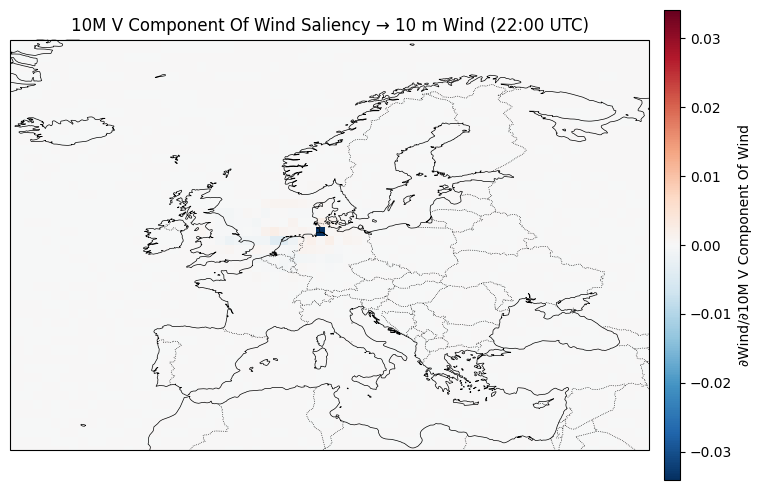

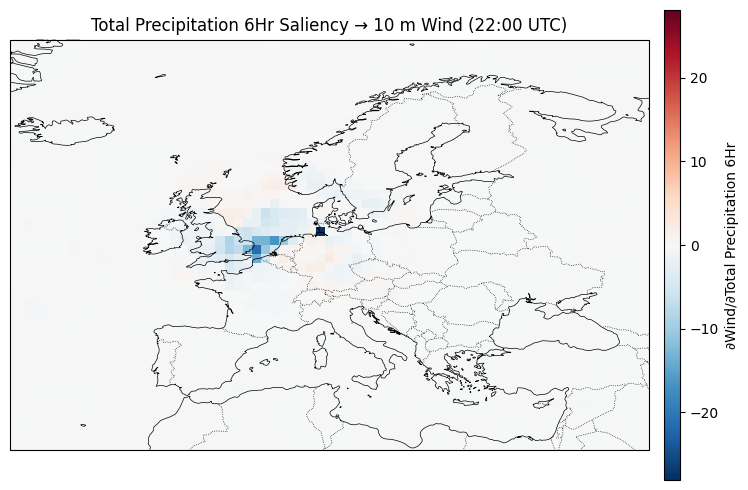

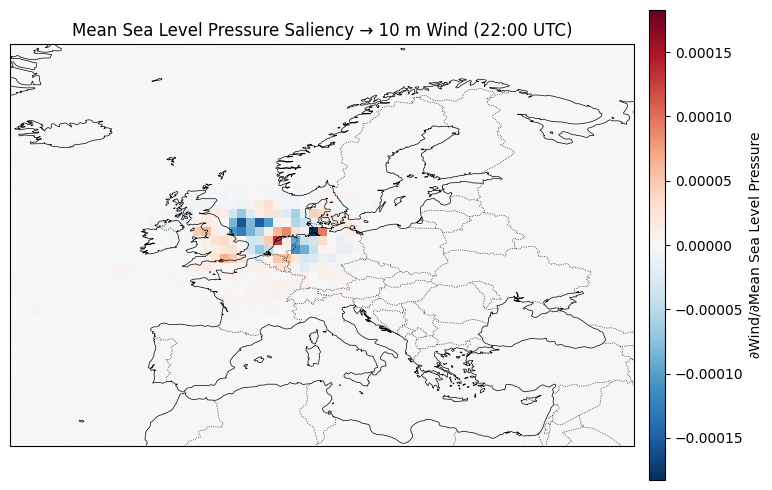

In [39]:
for surf_var in [
    "2m_temperature",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "total_precipitation_6hr",
    "mean_sea_level_pressure"
]:
    plot_surface_saliency(sal_ds, input_ds, surf_var, time_index=-1)

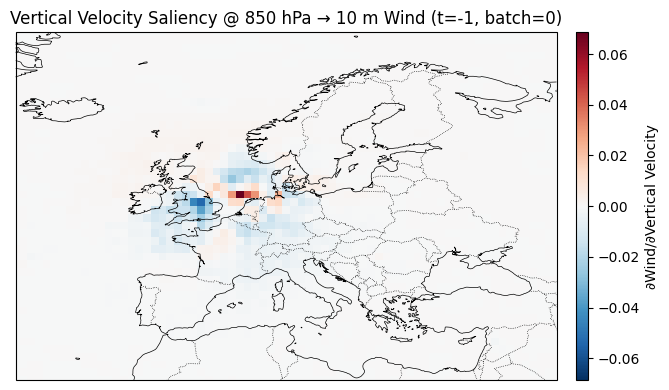

In [45]:
# variables: 
# geopotential, temperature, specific_humidity, 
# u_component_of_wind, v_component_of_wind, vertical_velocity

plot_atmospheric_saliency(
    sal_ds=sal_ds,
    input_ds=input_ds,
    varname="vertical_velocity",
    target_level=850.0,
    time_index=-1,
    batch_index=0,
    extent=[-25, 45, 30, 75],
    cmap="RdBu_r"
)